# Energy Sector Next-Day Movement Prediction

Final project — Fintech Workshop, Reichman University.

**Task:** binary classification — will an S&P 500 Energy stock rise more than 1% the next trading day?
**Prediction time:** daily at 4 PM market close.
**Dataset window:** through March 6, 2026.

Non-negotiable rules (from `CLAUDE.md`):
- No `train_test_split` — use roll-forward expanding window for time series.
- No look-ahead bias — every feature must use only data available by 4 PM on the prediction date.

# Stage 1 — Data Collection & Verification

This section covers Task 1.1 from `tasks/STAGE_1.md`: confirm the base dataset is complete and clean, and produce the data-overview numbers required by Stage 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Project-wide constants (kept at the top so they're easy to change later).
DATA_PATH = Path('../Data/sp500_Energy_dataset.csv')
THRESHOLD = 0.01  # 1% next-day return — confirmed with professor (used in Task 1.2)
EXPECTED_END_DATE = pd.Timestamp('2026-03-06')

pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 120)

## 1. Load the CSV

Date format in the source file is European (`DD/MM/YYYY`) — `dayfirst=True` is required or pandas silently misparses.

In [2]:
df = pd.read_csv(DATA_PATH, dayfirst=True, parse_dates=['date'])
df.head()

,date,ticker,sector,open,high,low,close,volume,daily_return_pct,1_d_return,vix_end_of_day,sp500_return_today
0,2022-03-29,APA,Energy,38.880,40.97,38.520,40.96,7534484.0,2.785445,0.59%,18.900000,1.225655
1,2022-03-30,APA,Energy,41.450,42.36,40.680,41.20,9015751.0,0.585938,0.32%,19.330000,-0.629370
2,2022-03-31,APA,Energy,41.060,42.77,40.800,41.33,7934454.0,0.315534,2.15%,20.559999,-1.565254
3,2022-04-01,APA,Energy,41.415,42.69,41.415,42.22,5005443.0,2.153399,1.80%,19.629999,0.341022
4,2022-04-04,APA,Energy,43.000,43.69,42.270,42.98,6946894.0,1.800095,-3.00%,18.570000,0.809094


## 2. Shape and dtypes

In [3]:
print('Shape:', df.shape)
df.info()

Shape: (20929, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20929 entries, 0 to 20928
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                20929 non-null  datetime64[ns]
 1   ticker              20929 non-null  object        
 2   sector              20929 non-null  object        
 3   open                20929 non-null  float64       
 4   high                20929 non-null  float64       
 5   low                 20929 non-null  float64       
 6   close               20929 non-null  float64       
 7   volume              20929 non-null  float64       
 8   daily_return_pct    20929 non-null  float64       
 9   1_d_return          20929 non-null  object        
 10  vix_end_of_day      20929 non-null  float64       
 11  sp500_return_today  20929 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(3)
memory usage: 1.9+ MB


## 3. Ticker coverage

How many distinct tickers, and how evenly are they covered? A ticker with materially fewer rows than the rest probably entered or left the index during the window.

In [4]:
n_tickers = df['ticker'].nunique()
print(f'Unique tickers: {n_tickers}')

ticker_counts = df['ticker'].value_counts().sort_values(ascending=False)
print('\nRows per ticker:')
print(ticker_counts)

Unique tickers: 22

Rows per ticker:
APA     988
BKR     988
XOM     988
COP     988
CVX     988
DVN     988
EOG     988
EQT     988
FANG    988
HAL     988
KMI     988
MPC     988
OKE     988
OXY     988
PSX     988
SLB     988
TPL     988
TRGP    988
VLO     988
WMB     988
CTRA    961
EXE     208
Name: ticker, dtype: int64


In [5]:
# Flag tickers with materially fewer rows than the median.
median_rows = ticker_counts.median()
low_coverage = ticker_counts[ticker_counts < 0.9 * median_rows]
print(f'Median rows per ticker: {int(median_rows)}')
if len(low_coverage) == 0:
    print('No tickers with <90% of median coverage.')
else:
    print('\nTickers with <90% of median coverage (likely index entry/exit):')
    print(low_coverage)

Median rows per ticker: 988

Tickers with <90% of median coverage (likely index entry/exit):
EXE    208
Name: ticker, dtype: int64


## 4. Date range and trading days

Per the professor, the data should end on or near **March 6, 2026**. We flag any deviation.

In [6]:
min_date = df['date'].min()
max_date = df['date'].max()
n_trading_days = df['date'].nunique()

print(f'Date range: {min_date.date()} → {max_date.date()}')
print(f'Total unique trading days: {n_trading_days}')
print(f'Expected end date: {EXPECTED_END_DATE.date()}')

delta = (EXPECTED_END_DATE - max_date).days
if delta == 0:
    print('Max date matches expectation exactly.')
else:
    print(f'Max date differs from expectation by {delta} day(s).')

Date range: 2022-03-29 → 2026-03-06
Total unique trading days: 988
Expected end date: 2026-03-06
Max date matches expectation exactly.


## 5. Missing values

In [7]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing cells: {int(missing.sum())}')

Missing values per column:
date                  0
ticker                0
sector                0
open                  0
high                  0
low                   0
close                 0
volume                0
daily_return_pct      0
1_d_return            0
vix_end_of_day        0
sp500_return_today    0
dtype: int64

Total missing cells: 0


## 6. Tickers present per date

Plotting the count of tickers reporting on each date. Drops here indicate tickers entering or leaving the S&P 500 Energy sector during the window — useful context for Stage 2 EDA and for any roll-forward training that needs to handle uneven panel shape.

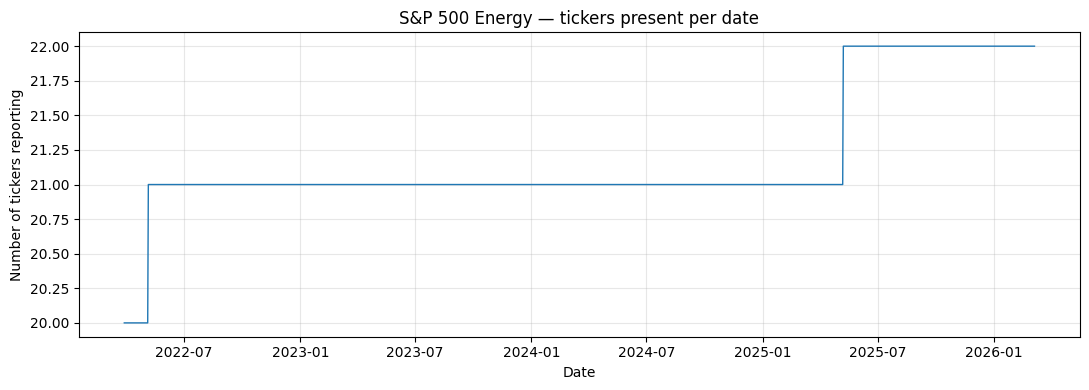

Min tickers on any date: 20
Max tickers on any date: 22
Most common count:     21


In [8]:
tickers_per_date = df.groupby('date')['ticker'].nunique().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tickers_per_date.index, tickers_per_date.values, linewidth=1.0)
ax.set_xlabel('Date')
ax.set_ylabel('Number of tickers reporting')
ax.set_title('S&P 500 Energy — tickers present per date')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f'Min tickers on any date: {tickers_per_date.min()}')
print(f'Max tickers on any date: {tickers_per_date.max()}')
print(f'Most common count:     {tickers_per_date.mode().iloc[0]}')

## 7. Findings summary

**Coverage.** The dataset has **20,929 rows × 12 columns** spanning **22 unique tickers** over **988 trading days** from **2022-03-29 to 2026-03-06**. The end date matches the professor's expectation exactly.

**Ticker balance.** 20 of the 22 tickers have the full 988 rows. Two have materially less coverage:
- **CTRA** — 961 rows (entered the panel a few weeks after the start).
- **EXE** — only 208 rows, well under the median. This is a recent addition to the S&P 500 Energy sector and is the lone ticker flagged by the <90% coverage check. Not a data quality bug, but we need to be aware when building per-ticker features in Stage 3 — short history can produce unstable rolling statistics.

**Panel shape.** Tickers reporting per date ranges from 20 to 22 (mode 21). The plot in section 6 shows the panel is not perfectly balanced — membership changes drive the step ups/downs. The roll-forward training loop in Stage 4 must handle uneven panel width without padding NaNs into features.

**Missing values.** Zero missing cells across all 12 columns. Note that the `1_d_return` column is currently a string with `%` suffix (dtype `object`) — that is expected and is cleaned in Task 1.2.

**Sector column.** All rows are labeled `Energy`, as expected.

**Conclusion.** Base dataset passes verification — proceed to Task 1.2 (binary label construction) and Task 1.4 (external Energy data sources).